In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


In [2]:
iris = datasets.load_iris()

In [3]:
X = iris.data[:100, 2:4]
y = iris.target[:100]

In [4]:
X 

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)  

In [6]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

In [7]:
def plot_decision_boundary(X,y, model, kernel_name):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max() +1
    y_min, y_max = X[:,1].min()-1, X[:,1].max() +1
    xx,yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

    Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy, Z, cmap=plt.cm.coolwarm, alpha = 0.8)
    plt.scatter(X[:,0], X[:,1], c=y, cmap = plt.cm.coolwarm)
    plt.xlabel('Petal length')
    plt.ylabel('Petal Width')
    plt.title(f'SVM with {kernel_name} kernel')
    plt.tight_layout()
    plt.show()


 -- Kernel: linear --
Accuracy is 1.00


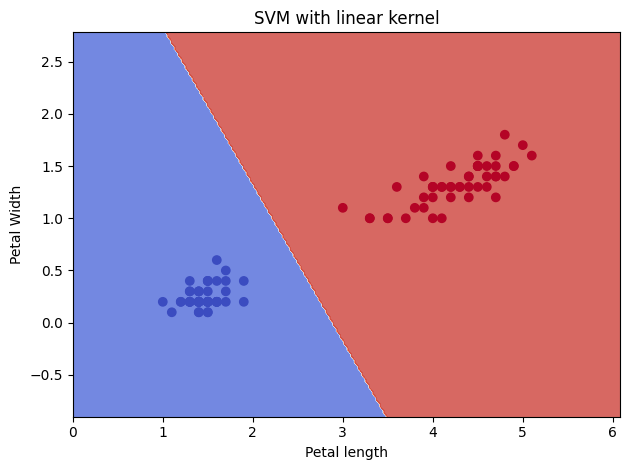


 -- Kernel: poly --
Accuracy is 1.00


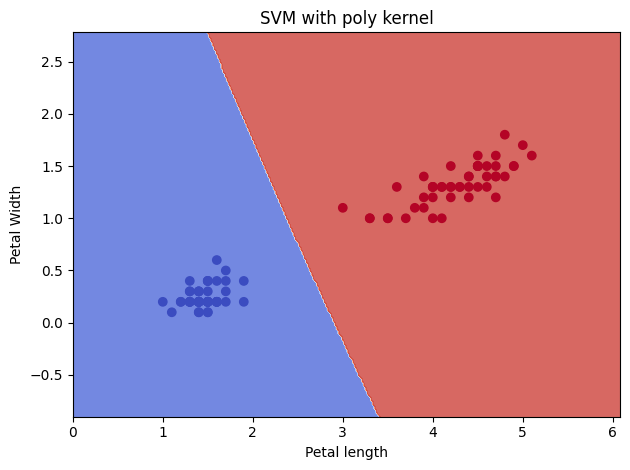


 -- Kernel: rbf --
Accuracy is 1.00


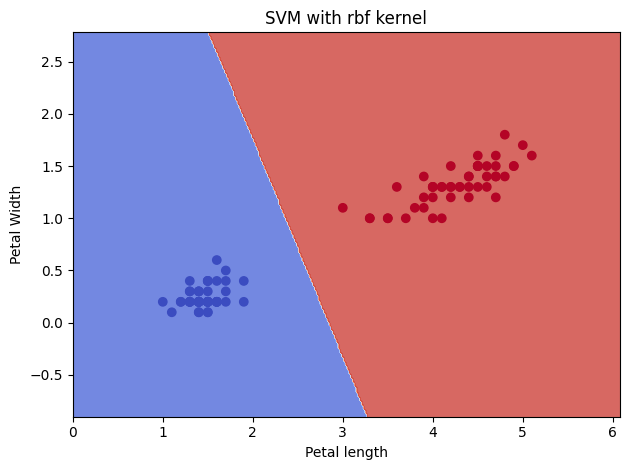


 -- Kernel: sigmoid --
Accuracy is 0.00


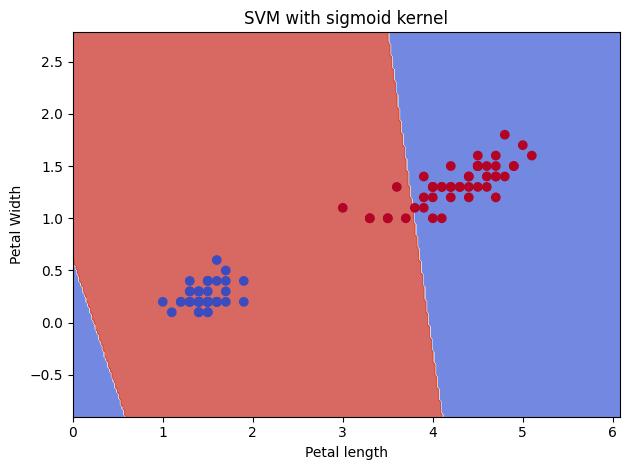

In [8]:
for kernel in kernels:
    print(f'\n -- Kernel: {kernel} --')
    model = SVC(kernel = kernel, degree=2 if kernel == 'poly' else int(0))
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f'Accuracy is {acc:.2f}')
    
    plot_decision_boundary(X,y, model, kernel)

In [9]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [10]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
param_grid = {
    'C': [0.1,1,10],
    'gamma': ['scale', 0.01,0.1,1],
    'kernel': ['linear', 'rbf', 'poly']
}


In [12]:
grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5, verbose=1, n_jobs=1)
grid.fit(X_train, y_train)
print(grid.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}


In [13]:
y_pred = grid.predict(X_test)
print('accuracy on test set:')
accuracy_score(y_test, y_pred)
print('classification_report:')
print(classification_report(y_test,y_pred, target_names= iris.target_names))

accuracy on test set:
classification_report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Text(0.5, 1.0, 'Non-Linear Data (Not separable by a line)')

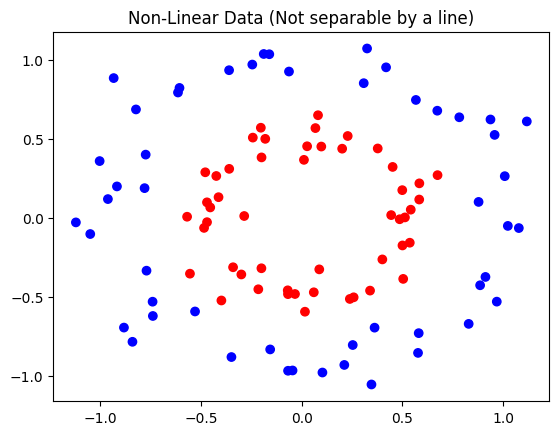

In [14]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=100, noise=0.1, factor=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title("Non-Linear Data (Not separable by a line)")

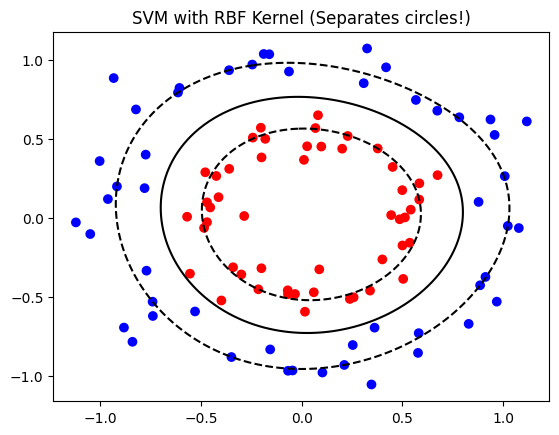

In [15]:
from sklearn.svm import SVC

# Train SVM with RBF kernel (kernel trick)
clf = SVC(kernel='rbf', gamma=1)
clf.fit(X, y)

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid for visualization
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[1], ylim[0], 100))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot boundary
ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
plt.title("SVM with RBF Kernel (Separates circles!)")
plt.show()

In [17]:
#Forest Data
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20],      # Depth of trees
    'min_samples_split': [2, 5, 10]   # Min samples to split a node
}

In [ ]:
# GRID Search for Random Forest

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
grid_search = GridSearchCV(model, param_grid, cv=5)  
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [21]:
# Scikit-Optimize

from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Load data
X, y = load_iris(return_X_y=True)


model = RandomForestClassifier()
param_space = {
    'n_estimators': (50, 200),  
    'max_depth': (1, 30)        
}

bayes_search = BayesSearchCV( model, param_space, n_iter=10, cv=5)

bayes_search.fit(X, y)

print("Best parameters:", bayes_search.best_params_)
print("Best score (CV accuracy):", bayes_search.best_score_)

Best parameters: OrderedDict([('max_depth', 30), ('n_estimators', 113)])
Best score (CV accuracy): 0.9666666666666668


In [ ]:
# Random Search

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

model = RandomForestClassifier()
param_grid = {
    'n_estimators': [50, 100, 200],  
    'max_depth': [None, 10, 20],      
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=5, random_state=42)

random_search.fit(X, y)

print("Best parameters:", random_search.best_params_)
print("Best score (CV accuracy):", random_search.best_score_)

Best parameters: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 10}
Best score (CV accuracy): 0.9666666666666668


In [24]:
#Evaluation

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))  

Test Accuracy: 1.0
